In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from nexuskan import *
from nexuskan import KAN
from nexuskan import nexusKAN

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# grad test

$x_1 x_3 + x_2 x_5 + x_4$

in: 5, out: 2

In [58]:
def some_func_to_add_dim(x, out_dim):
    x_res = torch.unsqueeze(x, dim=2)
    for i in range(out_dim - 1):
        x_res = torch.concat((x_res, torch.unsqueeze(x * 2., dim=2)), dim=2)
    
    return x_res

In [59]:
batch = 4
in_dim = 5
out_dim = 2

y_true = torch.tensor([[ -6., -28.],
                       [-21., -79.],
                       [36.,  138.],
                       [11.,  42.]]) # (batch, out_dim)
criterion = nn.MSELoss()

mask = torch.tensor([[0.9, -0.5], 
                     [-0.6, 0.6], 
                     [0.8, -0.5], 
                     [-0.9, -0.6],
                     [-0.6, 0.8]]).requires_grad_(True) # (in_dim, in_dim // 2)

x = torch.tensor([[2.0, 2.0, -2.0, 2.0, -2.0],
                  [3.0, -3.0, -3.0, -3.0, 3.0],
                  [4.0, -4.0, 4.0, 4.0, -4.0],
                  [4.0, -1.0, 2.0, 1.0, -2.0]]).requires_grad_(True) # (batch, in_dim)

y = some_func_to_add_dim(x, out_dim=out_dim) # (batch, in_dim, out_dim)

tau = 0.1
hard_mask = torch.sigmoid(mask / tau) # (in_dim, in_dim // 2)

# --- signs with threshold ---
# epsilon = 1e-8
# sign_data = torch.sign(y + epsilon) # (batch, in_dim, out_dim)
# mask_expanded = hard_mask[None, :, None, :] # (1, in_dim, 1, groups)
# sign_data_expanded = sign_data.unsqueeze(-1) # (batch, in_dim, out_dim, 1)
# selected_signs = torch.where(mask_expanded > 0.5, sign_data_expanded, 1.0) # (batch, in_dim, out_dim, in_dim // 2)
# final_sign = torch.prod(selected_signs, dim=1) # (batch, out_dim, in_dim // 2)
# masked_y_for_prod = torch.pow(torch.abs(y.unsqueeze(-1)), hard_mask[None, :, None, :]) # (batch, in_dim, out_dim, in_dim // 2)

# --- signs with linear representation ---
masked_y_for_prod = 1 - hard_mask[None, :, None, :] + hard_mask[None, :, None, :] * y.unsqueeze(-1) # (batch, in_dim, out_dim, in_dim // 2)
y_prod = torch.prod(masked_y_for_prod, dim=1) # (batch, out_dim, in_dim // 2)

masked_y_for_sum = y * (1. - torch.sum(hard_mask, dim=1)[:, None]) # (batch, in_dim, out_dim)

y = torch.sum(masked_y_for_sum, dim=1) + torch.sum(y_prod, dim=2)

print("y.size() =", y.size())
print(y)
loss = criterion(y, y_true)
loss.backward()
print(mask.grad)



y.size() = torch.Size([4, 2])
tensor([[ -5.9285, -27.7758],
        [-20.7027, -76.5018],
        [ 36.2673, 140.2303],
        [ 10.9046,  41.8166]], grad_fn=<AddBackward0>)
tensor([[ 1.2219e-03,  9.8583e+00],
        [-3.6339e+00,  6.6149e-01],
        [ 3.4755e-03,  2.8841e+01],
        [ 4.8847e-01,  1.0591e+01],
        [-1.0303e+01,  8.8898e-02]])


# **Dataset** $y = x_0 x_2 +  x_4 \sin{2 \pi x_3} + x_2$ and 2 learnable prod group

In [3]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
y = x[:, 0] * x[:, 2] + torch.sin(2 * torch.pi * x[:, 3]) * x[:, 4] + x[:, 1]
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
  
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

In [4]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, batch_size=512, epochs=1000):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    def relative_mse_loss(y_pred, y_true, epsilon=1e-8):
        # (batch_size, out_dim)
        squared_diff = (y_pred - y_true)**2
        # Нормализуем на квадрат истинного значения
        relative_diff = squared_diff / (y_true**2 + epsilon)
        return torch.mean(relative_diff)

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-6  # для L1 активаций 1.
    lamb_ent_acts = 1e-3  # для энтропии активаций 2.

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
                    
            new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            # train_loss = relative_mse_loss(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=1.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            # loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            # test_loss = relative_mse_loss(test_outputs, dataset['test_label'])
            test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')
            # for module in model.modules():
            #     if isinstance(module, NexusKANLayer):
            #         probs = torch.softmax(module.logits / module.tau, dim=-1)
            #         rounded_probs = probs.round(decimals=3)
            #         print(rounded_probs)
        

checkpoint directory created: ./model
saving model version 0.0


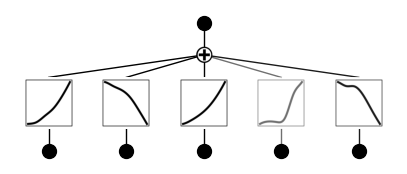

In [5]:
model = nexusKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [6]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

Epoch [10/100], Train Loss: 0.1439, Test Loss: 0.1207
Epoch [20/100], Train Loss: 0.0010, Test Loss: 0.0009
Epoch [30/100], Train Loss: 0.0008, Test Loss: 0.0007
Epoch [40/100], Train Loss: 0.0007, Test Loss: 0.0007
Epoch [50/100], Train Loss: 0.0007, Test Loss: 0.0006
Epoch [60/100], Train Loss: 0.0006, Test Loss: 0.0005
Epoch [70/100], Train Loss: 0.0006, Test Loss: 0.0005
Epoch [80/100], Train Loss: 0.0006, Test Loss: 0.0005
Epoch [90/100], Train Loss: 0.0006, Test Loss: 0.0005
Epoch [100/100], Train Loss: 0.0006, Test Loss: 0.0005


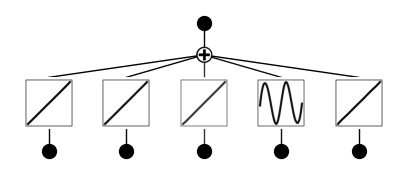

In [7]:
model.plot()

In [8]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[-2.6602, -1.7695, -0.9937, -0.2685,  0.2883,  0.7775,  1.1221,
           1.6434]],

        [[-2.1165, -1.4058, -0.7607, -0.2054,  0.2144,  0.5450,  0.7282,
           1.0009]],

        [[-1.6914, -1.1719, -0.5314, -0.0892,  0.1211,  0.0926, -0.0958,
          -0.3975]],

        [[-5.7033,  1.1398,  0.9377, -1.8950,  1.9062, -0.9756, -1.2419,
           5.4850]],

        [[-2.5726, -1.3699, -0.8221, -0.2154,  0.2185,  0.6453,  0.8342,
           1.4256]]], device='cuda:0')
act_fun.0.scale_base tensor([[1.3872],
        [0.8233],
        [0.7040],
        [0.1798],
        [1.0897]], device='cuda:0')
act_fun.0.scale_sp tensor([[0.9392],
        [0.5456],
        [0.2475],
        [0.7771],
        [0.8880]], device='cuda:0')
act_fun.0.logits tensor([[[-0.8779,  6.1763, -1.8066]],

        [[-1.5569, -1.9269,  3.1326]],

        [[-1.7850,  5.3833, -1.6557]],

        [[ 5.3705, -1.5168, -1.7378]],

        [[ 6.2958, -0.7386, -2.1134]]], device='cuda:0')
sym

In [18]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1., 0.]],

        [[0., 0., 1.]],

        [[0., 1., 0.]],

        [[1., 0., 0.]],

        [[1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)


# **Dataset** $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$ 

## LBFGS

In [343]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, epochs=1000, 
                    logits_requires_grad=True, splines_requires_grad=True,
                    use_full_batch=True, batch_size=512):
    """
    Обучение модели с оптимизатором LBFGS.
    
    Args:
        use_full_batch: если True — используется весь датасет за шаг (рекомендуется для LBFGS)
                        если False — эмуляция mini-batch (менее стабильно)
    """
    # Инициализация LBFGS
    optimizer = optim.LBFGS(model.parameters(), 
                           lr=lr, 
                           history_size=10, 
                           line_search_fn="strong_wolfe", 
                           tolerance_grad=1e-32, 
                           tolerance_change=1e-32)
    criterion = nn.MSELoss()
    
    lamb_l1_acts = 1e-3
    lamb_ent_acts = 1e-3

    for epoch in range(epochs):
        # === Обновление гиперпараметров (раз в эпоху, не внутри closure!) ===
        current_lr = lr
        # current_lr = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
        new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
        
        # Обновление requires_grad и tau для слоёв модели
        for module in model.modules():
            if isinstance(module, NexusKANLayer):
                module.logits.requires_grad = logits_requires_grad
                module.scale_base.requires_grad = splines_requires_grad
                module.scale_sp.requires_grad = splines_requires_grad
                module.coef.requires_grad = splines_requires_grad
                module.tau = new_tau
        
        # Обновление learning rate в оптимизаторе
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr
        
        # === Функция closure для LBFGS ===
        def closure():
            optimizer.zero_grad()
            
            if use_full_batch:
                # Полный датасет (рекомендуется)
                batch_x = dataset['train_input']
                batch_y = dataset['train_label']
            else:
                # Эмуляция mini-batch (не рекомендуется для LBFGS)
                idx = torch.randperm(dataset['train_input'].shape[0])[:batch_size]
                batch_x = dataset['train_input'][idx]
                batch_y = dataset['train_label'][idx]
            
            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            # lamb_ent_ops = 10.0
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=10.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # === Регуляризация активаций (L1 + энтропия) ===
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            # loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            loss.backward()
            return loss
        
        # === Шаг оптимизации ===
        optimizer.step(closure)
        
        # === Оценка на тесте ===
        with torch.no_grad():
            train_out = model(dataset['train_input'])
            train_loss = criterion(train_out, dataset['train_label'])
            test_out = model(dataset['test_input'])
            test_loss = criterion(test_out, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'--- Epoch [{epoch+1}/{epochs}], '
                  f'Train Loss: {train_loss.item():.4f}, '
                  f'Test Loss: {test_loss.item():.4f}')

## Adam

In [ ]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_tau_osc(step, total_steps, tau_start=2.0, tau_sup=1.0, tau_end=0.1, freq=7.0):
    top_th = tau_start * (tau_end / tau_start) ** (step / total_steps)
    bottom_th = tau_sup * (tau_end / tau_sup) ** (step / total_steps)
    osc = (top_th + bottom_th) + (top_th - bottom_th) * np.cos(freq * torch.pi * step / total_steps)
    return osc / 2

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

# def get_lamb_osc(step, total_steps, tau_start=2.0, tau_sup=1.0, tau_end=0.1, freq=3.0):
#     top_th = tau_start * (tau_end / tau_start) ** (step / total_steps)
#     bottom_th = tau_sup * (tau_end / tau_sup) ** (step / total_steps)
#     osc = (top_th + bottom_th) - (top_th - bottom_th) * np.cos(freq * torch.pi * step / total_steps)
#     return osc / 2

def fit_model(model, dataset, lr=0.1, batch_size=64, epochs=100, logits_requires_grad=True, splines_requires_grad=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    def relative_mse_loss(y_pred, y_true, epsilon=1e-8):
        # (batch_size, out_dim)
        squared_diff = (y_pred - y_true)**2
        # Нормализуем на квадрат истинного значения
        relative_diff = squared_diff / (y_true**2 + epsilon)
        return torch.mean(relative_diff)
        

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-3  # для L1 активаций 1.
    lamb_ent_acts = 1e-3  # для энтропии активаций 2.

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
            
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.logits.requires_grad = logits_requires_grad
                    
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.scale_base.requires_grad = splines_requires_grad
                    module.scale_sp.requires_grad = splines_requires_grad
                    module.coef.requires_grad = splines_requires_grad
                   
            # new_tau = 2.0 
            new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            # train_loss = criterion(outputs, batch_y)
            train_loss = relative_mse_loss(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            # lamb_ent_ops = 10.0
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=10.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            # loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            test_loss = relative_mse_loss(test_outputs, dataset['test_label'])
            # test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'--- Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')
            # for module in model.modules():
            #     if isinstance(module, NexusKANLayer):
            #         probs = torch.softmax(module.logits / module.tau, dim=-1)
            #         rounded_probs = probs.round(decimals=3)
            #         print("tau: ", module.tau)
            #         print(rounded_probs)

## **Test 0:** $y = x_0 x_2 +  x_4 \sin{2 \pi x_3} + x_2$ 

In [ ]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
y = x[:, 0] * x[:, 2] + torch.sin(2 * torch.pi * x[:, 3]) * x[:, 4] + x[:, 1]
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
  
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


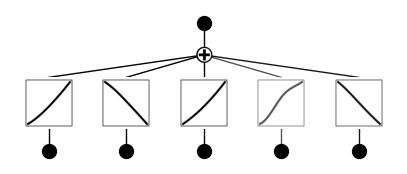

In [146]:
model = nexusKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [147]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.9135, Test Loss: 4.9779
--- Epoch [20/100], Train Loss: 0.8659, Test Loss: 6.6085
--- Epoch [30/100], Train Loss: 0.8134, Test Loss: 9.7739
--- Epoch [40/100], Train Loss: 0.6985, Test Loss: 11.1424
--- Epoch [50/100], Train Loss: 0.6659, Test Loss: 9.9628
--- Epoch [60/100], Train Loss: 0.5967, Test Loss: 17.7895
--- Epoch [70/100], Train Loss: 0.7144, Test Loss: 1.0411
--- Epoch [80/100], Train Loss: 0.7202, Test Loss: 0.8357
--- Epoch [90/100], Train Loss: 0.7102, Test Loss: 0.9661
--- Epoch [100/100], Train Loss: 0.6624, Test Loss: 1.2238


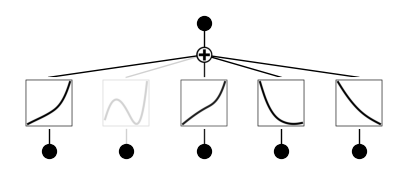

In [148]:
model.plot()

In [149]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.5750, 0.4250, 0.0000]],

        [[0.1420, 0.8580, 0.0000]],

        [[0.7050, 0.2950, 0.0000]],

        [[1.0000, 0.0000, 0.0000]],

        [[0.0000, 1.0000, 0.0000]]], device='cuda:0', grad_fn=<RoundBackward1>)


## **Test 1 :** $y = \frac{x_0}{x_1} + \frac{x_2}{x_3}$

In [119]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


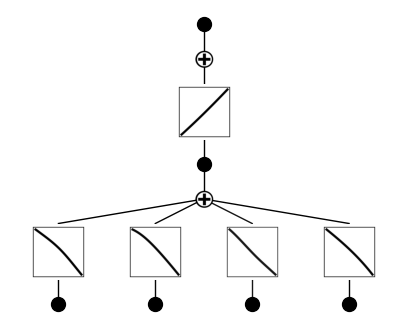

In [120]:
model = nexusKAN(width=[4, 1, 1], grid=5, k=3, seed=42, 
                #  grid_range=[0.5, 4.0], 
                 device=device)
model(dataset['train_input'])
model.plot()

In [121]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.0315, Test Loss: 0.0258
--- Epoch [20/100], Train Loss: 0.0060, Test Loss: 0.0030
--- Epoch [30/100], Train Loss: 0.0037, Test Loss: 0.0024
--- Epoch [40/100], Train Loss: 0.0035, Test Loss: 0.0022
--- Epoch [50/100], Train Loss: 0.0035, Test Loss: 0.0021
--- Epoch [60/100], Train Loss: 0.0037, Test Loss: 0.0021
--- Epoch [70/100], Train Loss: 0.0035, Test Loss: 0.0027
--- Epoch [80/100], Train Loss: 0.0033, Test Loss: 0.0022
--- Epoch [90/100], Train Loss: 0.0032, Test Loss: 0.0021
--- Epoch [100/100], Train Loss: 0.0032, Test Loss: 0.0021


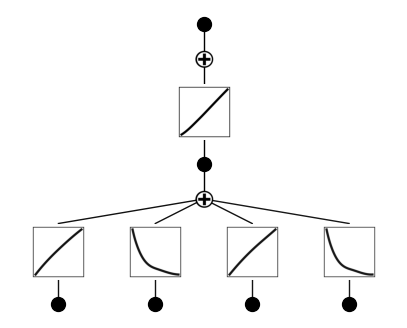

In [122]:
model.plot()

In [123]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1., 0.]],

        [[0., 1., 0.]],

        [[1., 0., 0.]],

        [[1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


## **Test 2 :** $y = \frac{x_0}{x_1}$

In [124]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 2) + start_range
# x[:, 1] = 0.5

y = x[:, 0] / x[:, 1]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

In [125]:
model = nexusKAN(width=[2, 1, 1], grid=5, k=3, seed=42, 
                #  grid_range=[0.5, 4.0], 
                 device=device)

checkpoint directory created: ./model
saving model version 0.0


In [126]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.0055, Test Loss: 0.0047
--- Epoch [20/100], Train Loss: 0.0063, Test Loss: 0.0073
--- Epoch [30/100], Train Loss: 0.0081, Test Loss: 0.0060
--- Epoch [40/100], Train Loss: 0.0027, Test Loss: 0.0017
--- Epoch [50/100], Train Loss: 0.0023, Test Loss: 0.0013
--- Epoch [60/100], Train Loss: 0.0039, Test Loss: 0.0019
--- Epoch [70/100], Train Loss: 0.0018, Test Loss: 0.0011
--- Epoch [80/100], Train Loss: 0.0017, Test Loss: 0.0010
--- Epoch [90/100], Train Loss: 0.0016, Test Loss: 0.0009
--- Epoch [100/100], Train Loss: 0.0016, Test Loss: 0.0009


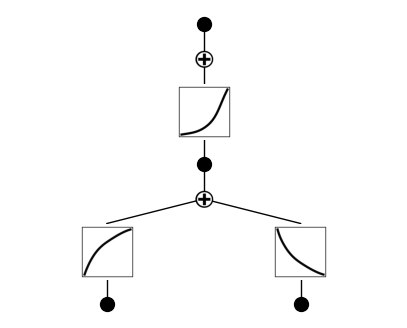

In [127]:
model.plot()

In [128]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1.]],

        [[0., 1.]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


In [129]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[ 1.1586e-02,  3.6656e-02, -9.0091e+00, -2.3424e+00, -9.4939e-01,
          -6.1430e-01, -3.1119e-01, -2.6038e-01]],

        [[ 4.0875e-03,  2.7029e-02,  2.7089e+01,  1.0128e+00, -6.0060e-01,
          -7.2837e-01, -6.9813e-01, -2.8815e-01]]], device='cuda:0')
act_fun.0.scale_base tensor([[-0.1798],
        [-0.8294]], device='cuda:0')
act_fun.0.scale_sp tensor([[1.1044],
        [0.7918]], device='cuda:0')
act_fun.0.logits tensor([[[0.1073, 1.0632]],

        [[0.2516, 1.2077]]], device='cuda:0')
act_fun.1.coef tensor([[[0.0641, 0.1329, 0.3412, 0.7762, 1.9507, 2.3471, 1.5626, 0.6863]]],
       device='cuda:0')
act_fun.1.scale_base tensor([[-0.0282]], device='cuda:0')
act_fun.1.scale_sp tensor([[2.8325]], device='cuda:0')
act_fun.1.logits tensor([[[0.2695]]], device='cuda:0')
symbolic_fun.0.affine tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.]]], device='cuda:0')
symbolic_fun.1.affine tensor([[[0., 0., 0., 0.]]], device='cuda:0')


## **Test 3 :** $y = \frac{\frac{x_0}{x_1}}{\frac{x_2}{x_3}}$

In [130]:
end_range = 3.0
start_range = 1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] / x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

In [131]:
model = nexusKAN(width=[4, 2, 1], grid=5, k=3, seed=42, grid_range=[0.5, 4.0], device=device)

checkpoint directory created: ./model
saving model version 0.0


In [132]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.0023, Test Loss: 0.0006
--- Epoch [20/100], Train Loss: 0.0005, Test Loss: 0.0004
--- Epoch [30/100], Train Loss: 0.0019, Test Loss: 0.0012
--- Epoch [40/100], Train Loss: 0.0005, Test Loss: 0.0004
--- Epoch [50/100], Train Loss: 0.0003, Test Loss: 0.0003
--- Epoch [60/100], Train Loss: 0.0003, Test Loss: 0.0002
--- Epoch [70/100], Train Loss: 0.0002, Test Loss: 0.0001
--- Epoch [80/100], Train Loss: 0.0001, Test Loss: 0.0001
--- Epoch [90/100], Train Loss: 0.0002, Test Loss: 0.0001
--- Epoch [100/100], Train Loss: 0.0003, Test Loss: 0.0004


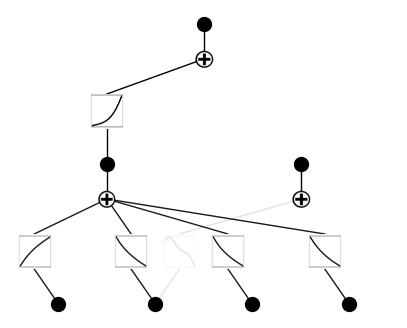

In [133]:
model.plot()

In [134]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.0000, 0.0000, 0.9990],
         [0.0000, 1.0000, 0.0000]],

        [[0.0000, 0.0000, 1.0000],
         [0.0040, 0.9960, 0.0000]],

        [[0.0000, 0.0000, 1.0000],
         [0.3560, 0.6440, 0.0000]],

        [[0.0190, 0.2880, 0.6930],
         [0.9960, 0.0040, 0.0000]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[0.0000, 1.0000]],

        [[0.9220, 0.0780]]], device='cuda:0', grad_fn=<RoundBackward1>)


## $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$

In [139]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 8) + start_range

# x[:, 1] = 5.5
# x[:, 3] = 6.4
# x[:, 5] = 8.5
# x[:, 7] = 7.6

y = (x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]) / (x[:, 4] / x[:, 5] + x[:, 6] / x[:, 7])

dataset = {
    'train_input': x[:num_samples],
    'train_label': y[:num_samples].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 8]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


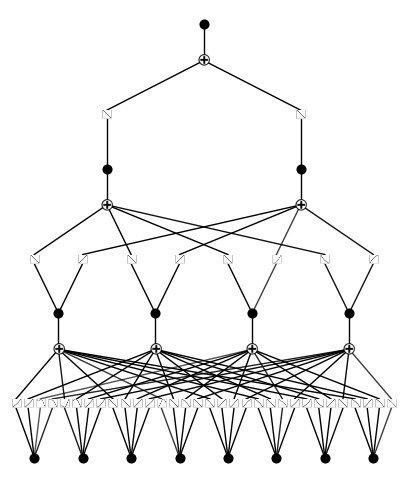

In [140]:
model = nexusKAN(width=[8, 4, 2, 1], grid=5, k=3, seed=42, 
                #  grid_range=[3.0, 20.0],
                 device=device)
model(dataset['train_input'])
model.plot()

In [141]:
fit_model(model=model, 
          dataset=dataset,
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.0331, Test Loss: 0.0290
--- Epoch [20/100], Train Loss: 0.0107, Test Loss: 0.0133
--- Epoch [30/100], Train Loss: 0.0035, Test Loss: 0.0027
--- Epoch [40/100], Train Loss: 0.0026, Test Loss: 0.0029
--- Epoch [50/100], Train Loss: 0.0016, Test Loss: 0.0015
--- Epoch [60/100], Train Loss: 0.0034, Test Loss: 0.0019
--- Epoch [70/100], Train Loss: 0.0059, Test Loss: 0.0024
--- Epoch [80/100], Train Loss: 0.0025, Test Loss: 0.0020
--- Epoch [90/100], Train Loss: 0.0026, Test Loss: 0.0020
--- Epoch [100/100], Train Loss: 0.0017, Test Loss: 0.0021


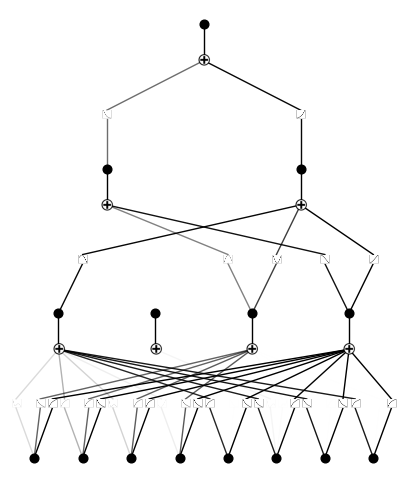

In [142]:
model.plot()

In [143]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.0440, 0.8420, 0.0590, 0.0560, 0.0000],
         [0.0770, 0.0020, 0.0590, 0.8620, 0.0000],
         [0.0000, 0.0010, 0.0000, 0.0000, 0.9990],
         [0.0380, 0.1450, 0.0000, 0.0290, 0.7880]],

        [[0.2120, 0.6640, 0.0420, 0.0820, 0.0000],
         [0.3780, 0.6070, 0.0050, 0.0100, 0.0000],
         [0.0020, 0.0000, 0.0000, 0.0000, 0.9980],
         [0.0000, 0.9900, 0.0000, 0.0100, 0.0000]],

        [[0.0710, 0.6930, 0.0160, 0.0940, 0.1260],
         [0.3730, 0.6080, 0.0000, 0.0190, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 1.0000]],

        [[0.0420, 0.8220, 0.0020, 0.1350, 0.0000],
         [0.1880, 0.0000, 0.8110, 0.0010, 0.0000],
         [0.0010, 0.0000, 0.0000, 0.0000, 0.9990],
         [0.0000, 0.0000, 0.0000, 0.0000, 1.0000]],

        [[0.0000, 0.0000, 1.0000, 0.0000, 0.0000],
         [0.3760, 0.6100, 0.0140, 0.0010, 0.0000],
         [0.2880, 0.3190, 0.1960, 0.1970, 0.0000],
         [0.7540, 0.000